In [1]:
import numpy
import sys
import os
import matplotlib.pyplot as plt
# import skimage
import nrrd
from scipy import ndimage
import meshio
from skimage.morphology import skeletonize
from scipy.interpolate import splprep, splev
from sklearn.decomposition import PCA
from scipy.spatial import cKDTree
from scipy.interpolate import UnivariateSpline
import trimesh

from scipy.spatial import cKDTree, Delaunay
from scipy.interpolate import UnivariateSpline
from skimage import measure

sys.path.insert(0, "../src")  # add Folder_2 path to search list

from meshing_functions import getSurfaceMesh, tetra_mesh_from_stl, tetra_shell_from_two_surfaces, set_the_offset, export_centerline


pixel_spacing = numpy.loadtxt("/Users/skardova/Documents/MRI_data/Brain/Comprehensive ultrahigh resolution/ses-4712/pixel_spacing.txt")

base = "/Users/skardova/Documents/MRI_data/Brain/Comprehensive ultrahigh resolution/ses-4712/"

# offset = numpy.loadtxt("/Users/skardova/Documents/MRI_data/Brain/Comprehensive ultrahigh resolution/ses-4712/meshes/offset.txt")


in_folder = "segment_final/"    
out_folder = "spline_experiment/"

folder = "Fourier-spline_meshes-from-masks/"

if not os.path.isdir(base + folder):
    os.mkdir(base + folder)


## Load segments, pixel spacing etc

In [2]:

filename = "Segmentation_1.seg.nrrd"
export_name = base + folder + filename[:-8]

eyeball_id = 1
muslce_ids = [2,3,4,5]
pairs = [(0,2), (1,3)]

lense_id = 7

background_id = -1


data, header = nrrd.read(base + in_folder + filename)
print(data.shape)



id_max = numpy.max(data)

print("pixel spacing = ",pixel_spacing)
print("id = ", id_max )

print("dimensions = ", data.shape)

if pixel_spacing[2]!= pixel_spacing[1]:
    print("resampling")
    factor = pixel_spacing[2]/pixel_spacing[1]
    data = ndimage.zoom(data, [1,1,factor], order = 0)


print("dimensions = ", data.shape)

id = int(numpy.max(data))
print("id = ", id)




(110, 150, 155)
pixel spacing =  [0.5 0.5 0.5]
id =  7
dimensions =  (110, 150, 155)
dimensions =  (110, 150, 155)
id =  7


## Create initial meshes

In [3]:
muscles = []

for id in range(1,numpy.max(data)+1):
    if id != background_id:
    # for id in range(3,4):
        print("id = ", id)


        if len(numpy.where((data>id-0.5) & (data<id+0.5 ))[0])>0:

            mask = numpy.zeros(data.shape, dtype=numpy.uint8)
            mask[(data>id-0.5) & (data<id+0.5 )]=1

            print(len(numpy.where(mask==1)[0]))


            numpy.save(export_name +"_filtered_surf_id_"+str(id), mask)

            if id ==eyeball_id:

                mask = ndimage.median_filter(mask, size=1)
                mask[mask<0.5]=0
                mask[mask>=0.5]=1

                mesh_surf = getSurfaceMesh(mask, export_name +"_surf_id_"+str(id)+".stl", pixel_spacing[0], True )

                mask_voxels = numpy.argwhere(mask == 1)  # shape (N, 3), coordinates in (z, y, x)
                # compute mean voxel position
                offset = mask_voxels.mean(axis=0)*pixel_spacing[0]  # [z_mean, y_mean, x_mean]
                numpy.savetxt(base + folder + "offset.txt", offset)

                mask_eye = mask

            if id in muslce_ids:
                print("Muscle")

                muscles.append(mask)
                mesh_surf = getSurfaceMesh(mask, export_name +"_surf_id_"+str(id)+".stl", pixel_spacing[0], False )

            if id == lense_id:
                mask = ndimage.median_filter(mask, size=1)
                mask[mask<0.5]=0
                mask[mask>=0.5]=1

                mesh_surf = getSurfaceMesh(mask, export_name +"_surf_id_"+str(id)+".stl", pixel_spacing[0], False )


id =  1
65767
Problem edges: 0
Outer and inner surfaces written.
id =  2
8436
Muscle
Problem edges: 4
written file:  /Users/skardova/Documents/MRI_data/Brain/Comprehensive ultrahigh resolution/ses-4712/Fourier-spline_meshes-from-masks/Segmentation_1._surf_id_2.stl
id =  3
4587
Muscle
Problem edges: 0
written file:  /Users/skardova/Documents/MRI_data/Brain/Comprehensive ultrahigh resolution/ses-4712/Fourier-spline_meshes-from-masks/Segmentation_1._surf_id_3.stl
id =  4
7222
Muscle
Problem edges: 1
written file:  /Users/skardova/Documents/MRI_data/Brain/Comprehensive ultrahigh resolution/ses-4712/Fourier-spline_meshes-from-masks/Segmentation_1._surf_id_4.stl
id =  5
6801
Muscle
Problem edges: 6
written file:  /Users/skardova/Documents/MRI_data/Brain/Comprehensive ultrahigh resolution/ses-4712/Fourier-spline_meshes-from-masks/Segmentation_1._surf_id_5.stl
id =  6
6465
id =  7
1372
Problem edges: 4
written file:  /Users/skardova/Documents/MRI_data/Brain/Comprehensive ultrahigh resolution/s

## Lense axis

In [4]:
mesh = trimesh.load(export_name +"_surf_id_"+str(lense_id)+".stl")
# mesh.vertices = (mesh.vertices + offset) / pixel_spacing

lense_center = mesh.vertices.mean(axis=0)

print("lense_center = ", lense_center)

X = mesh.vertices - lense_center

_, _, vh = numpy.linalg.svd(X)

axis_direction = vh[-1]  # first principal axis


def axis(t):
    return lense_center + t * axis_direction


axis_points = [axis(-20.0), axis(20.0)]

export_centerline(axis_points, 1.0 , base + folder + "lense_axis.vtp", [0,0,0])

# # # # # # # # # # # # # # # # # # # # # # # # # # # # # 

target_point =  axis(-2.25)/pixel_spacing[0]

print("target_point = ", target_point)

lense_center =  [34.74798285 63.83954948 24.45071852]
target_point =  [ 69.28843289 123.27184881  49.78635298]


## Section curve

- eyeball mesh ∩ place perpendicular to lense axis
- output: section curve

In [5]:
eyeball_mesh = trimesh.load(export_name +"_surf_id_"+str(eyeball_id)+"_outer.stl")

section = eyeball_mesh.section(
    plane_origin=target_point*pixel_spacing[0],
    plane_normal=axis_direction
)

section_curve = []

for entity in section.entities:
    idx = entity.points  # ordered indices
    
    for i in range(len(idx) - 1):
        section_curve.append([idx[i], idx[i+1]])

meshio.write(
    base + folder + "section_curve_A.vtk",
    meshio.Mesh(
        points=section.vertices,
        cells=[("line", numpy.array(section_curve))]
    )
)

## Section curve B & radial expansion


In [6]:
target_point_B =  axis(-10)/pixel_spacing[0]

section_B = eyeball_mesh.section(
    plane_origin=target_point_B*pixel_spacing[0],
    plane_normal=axis_direction
)

section_curve_B = []

for entity in section_B.entities:
    idx = entity.points  # ordered indices
    
    for i in range(len(idx) - 1):
        section_curve_B.append([idx[i], idx[i+1]])


# Center point in physical space 
center_physical = target_point_B * pixel_spacing[0]

original_vertices = numpy.array(section_B.vertices)

# Radial vectors from the center 
radial_vectors = original_vertices - center_physical

magnitudes = numpy.linalg.norm(radial_vectors, axis=1, keepdims=True)
normalized_vectors = radial_vectors / (magnitudes + 1e-8)



# Expand outward by xx mm 
expansion_distance = 2.1  
expanded_vertices = original_vertices + (normalized_vectors * expansion_distance)

section_B.vertices = expanded_vertices

# 6. Rebuild the section_curve line segments using the new expanded coordinates
expanded_section_curve = []
for entity in section_B.entities:
    idx = entity.points  # ordered indices within this specific entity
    
    for i in range(len(idx) - 1):
        # We map the local entity indices directly to our expanded_vertices array
        expanded_section_curve.append([idx[i], idx[i+1]])

meshio.write(
    base + folder + "section_curve_B.vtk",
    meshio.Mesh(
        points=section_B.vertices,
        cells=[("line", numpy.array(expanded_section_curve))]
    )
)

## Functions: 
### Fit centerlines with/without additional constraints

In [7]:
def fit_target_constrained_spline(binned_centers, target_point, smoothing_factor=1.5):
    """
    binned_centers: (N, 3) array of centers from the mask
    target_point: (3,) array [z, y, x] where the object should end
    """
    # 1. Append the target point to the end of your centers
    # We ensure target_point is shaped correctly for concatenation
    target_point = numpy.array(target_point).reshape(1, 3)
    constrained_points = numpy.concatenate([binned_centers, target_point], axis=0)
    
    # 2. Assign Weights (w)
    # We give the target point a very high weight (e.g., 10) 
    # and the noisy data points a lower weight (e.g., 1)
    weights = numpy.ones(len(constrained_points))
    weights[-1] = 20.0  # Force the spline to prioritize hitting the target
    
    # 3. Fit the Spline
    # We use the transpose .T because splprep expects (3, N)
    try:
        # Note: 'w' is the weights, 's' is the overall smoothing
        tck, u = splprep(constrained_points.T, w=weights, s=smoothing_factor, k=3)
        
        # 4. Evaluate from 0 to 1
        # Since the target is now the last point in the data, 
        # u=1.0 will correspond to the target point.
        u_new = numpy.linspace(-0.05, 1.0, 160)
        smooth_centerline = numpy.array(splev(u_new, tck)).T
        
        return smooth_centerline
    except Exception as e:
        print(f"Constrained spline fit failed: {e}")
        return None
    
def fit_3_constrained_spline(binned_centers, target_1, target_2, target_3, smoothing_factor=1.5):
    """
    Fits a spline through binned centers and 3 target guiding points,
    """
    # 1. Combine all points into one unordered pool
    target_1 = numpy.array(target_1).reshape(1, 3)
    target_2 = numpy.array(target_2).reshape(1, 3)
    target_3 = numpy.array(target_3).reshape(1, 3)
    
    unordered_points = numpy.concatenate([binned_centers, target_1], axis=0)
    
    # 2. Use PCA  to find the true main orientation axis
    pca = PCA(n_components=1)
    projection = pca.fit_transform(unordered_points)
    
    # 3. Sort ALL points based on their position along this principal axis
    sort_idx = numpy.argsort(projection.flatten())
    constrained_points = unordered_points[sort_idx]

    constrained_points = numpy.concatenate([constrained_points, target_2, target_3], axis=0)
    
    # 4. Flip check (Ensure Target 3 is at the end)
    distances_to_end = numpy.linalg.norm(constrained_points - target_3, axis=1)
    if numpy.argmin(distances_to_end) == 0:
        constrained_points = numpy.flip(constrained_points, axis=0)

    # 5. Assign Weights dynamically by finding where the targets landed
    weights = numpy.ones(len(constrained_points))
    
    for target in [target_1]:
        distances = numpy.linalg.norm(constrained_points - target, axis=1)
        matched_idx = numpy.argmin(distances)
        weights[matched_idx] = 50
    
    weights[0] = 20
    weights[-1] = 20

    # 6. Fit the Spline
    try:
        tck, u = splprep(constrained_points.T, w=weights, s=smoothing_factor, k=3)
        
        # Evaluate slightly past the boundaries to allow mathematical extension
        u_new = numpy.linspace(-0.08, 1.0, 160)
        smooth_centerline = numpy.array(splev(u_new, tck)).T
        
        return smooth_centerline
    
    except Exception as e:
        print(f"PCA-Ordered 3-point constrained spline fit failed: {e}")
        return None
    

def fit_dual_constrained_spline(binned_centers, target_1, target_2, smoothing_factor=1.5):
    """
    binned_centers: (N, 3) array of centers from the mask
    target_1: (3,) array where the object should begin
    target_2: (3,) array where the object should end
    """
    # 1. Prepare the sequence: [Start, Binned Data, End]
    points = [
        binned_centers,
        numpy.array(target_1).reshape(1, 3),
        numpy.array(target_2).reshape(1, 3)
    ]
    constrained_points = numpy.concatenate(points, axis=0)
    
    # 2. Assign Weights
    # Weights[0] is Start, Weights[-1] is End. 
    # High values force the spline to hit those exact coordinates.
    weights = numpy.ones(len(constrained_points))
    weights[0] = 50.0  # Force start
    weights[-1] = 50.0 # Force end
    
    # 3. Fit the Spline
    # We pass the weights array to 'w'
    try:
        tck, u = splprep(constrained_points.T, w=weights, s=smoothing_factor, k=3)
        
        # 4. Evaluate
        # u=0.0 will be target_start, u=1.0 will be target_end
        u_new = numpy.linspace(-0.05, 1.0, 160)
        smooth_centerline = numpy.array(splev(u_new, tck)).T
        
        return smooth_centerline
    except Exception as e:
        print(f"Dual constrained spline fit failed: {e}")
        return None

def fit_analytical_centerline(mask, target_point, ignored_nodes, n_bins=20, extension_factor=0.2):
        # 1. Get all voxel coordinates (Z, Y, X)
        points = numpy.argwhere(mask == 1).astype(float)
        
        if len(points) < 10:
            return None

        # 2. Find the main orientation using PCA
        pca = PCA(n_components=1)
        # Project points onto the first principal component 
        projection = pca.fit_transform(points)
        
        # 3. Sort points based on their position along the principal axis
        sort_idx = numpy.argsort(projection.flatten())

        sort_idx = sort_idx[int(len(sort_idx)*ignored_nodes):int(len(sort_idx)*(1-ignored_nodes))]

        sorted_points = points[sort_idx]
        sorted_projection = projection[sort_idx].flatten()

        # 4. Create "Binned Centers" to handle the noise
        # Fit to the average center of 'n' slices
        bins = numpy.linspace(sorted_projection.min(), sorted_projection.max(), n_bins)
        binned_centers = []
        
        for i in range(len(bins)-1):
            # Find points that fall within this slice of the object
            mask_slice = (sorted_projection >= bins[i]) & (sorted_projection < bins[i+1])
            if numpy.any(mask_slice):
                center = sorted_points[mask_slice].mean(axis=0)
                binned_centers.append(center)
        
        binned_centers = numpy.array(binned_centers)

        # # 5. Fit the Spline to the centers
        # # Smoothing 's' can be lower here because the binning already cleaned the noise
        tck, u = splprep(binned_centers.T, s=3.5, k=2)
        
        # # 6. Extend the object
        # # Evaluating from 0.0 to 1+extension extends the centerline
        smooth_centerline = numpy.array(splev(numpy.linspace(-extension_factor, 1.0 + extension_factor, 100), tck)).T

        if len(target_point)==0:
            return smooth_centerline
        
        if len(target_point)==1:
            smooth_centerline_extended = fit_target_constrained_spline(binned_centers, target_point[0])
            return smooth_centerline, smooth_centerline_extended
        
        if len(target_point)==2:
            smooth_centerline_extended = fit_dual_constrained_spline(binned_centers, target_point[0], target_point[1] )
            return smooth_centerline, smooth_centerline_extended

        if len(target_point)==3:
            smooth_centerline_extended = fit_3_constrained_spline(binned_centers, target_point[0], target_point[1], target_point[2] )
            return smooth_centerline, smooth_centerline_extended    


## Functions:
### Get insertion points ~ section curve / fitted planes

In [8]:
def fit_plane_to_two_centerlines(centerline1, centerline2):
    # 1. Combine all points from both centerlines into one cloud
    points = numpy.vstack((centerline1, centerline2))
    
    # 2. Calculate the centroid (the average point)
    centroid = numpy.mean(points, axis=0)
    
    # 3. Center the points by subtracting the centroid
    centered_points = points - centroid
    
    # 4. Use Singular Value Decomposition
    _, _, vh = numpy.linalg.svd(centered_points)
    
    # 5. The normal vector 'n' is the last row of Vh 
    # (the direction with the least variance/spread)
    normal = vh[-1]
    
    return centroid, normal/numpy.linalg.norm(normal)

def find_plane_curve_intersections(section, section_curve, plane_centroid, plane_normal):
    intersections = []
    
    # Normalize plane normal just in case
    plane_normal = plane_normal / numpy.linalg.norm(plane_normal)
    
    vertices = section.vertices
    
    for start_idx, end_idx in section_curve:
        p1 = vertices[start_idx]
        p2 = vertices[end_idx]
        
        # Signed distances to the plane
        d1 = numpy.dot(p1 - plane_centroid, plane_normal)
        d2 = numpy.dot(p2 - plane_centroid, plane_normal)
        
        # Check if the segment crosses the plane
        if d1 * d2 < 0:
            # Linear interpolation to find the exact crossing point
            t = abs(d1) / (abs(d1) + abs(d2))
            intersect_pt = p1 + t * (p2 - p1)
            intersections.append(intersect_pt)
            
    return numpy.array(intersections)



In [9]:
extended_centerlines = []
centerlines = []
extended_centerlines_1 = []

# target_point = point on the lense axis

for muscle_id in range(len(muslce_ids)):
    mask = muscles[muscle_id]
    ignored_nodes = 0.01

    centerline, centerline_ext_1 = fit_analytical_centerline(mask, [target_point], ignored_nodes, n_bins=15, extension_factor=0.15)
    
    centerlines.append(centerline)
    extended_centerlines.append(centerline_ext_1)


    export_centerline(centerline_ext_1, pixel_spacing[0], base + folder + "centerline_exttended_1_id_"+str(muslce_ids[muscle_id])+".vtp", [0,0,0])
    export_centerline(centerline, pixel_spacing[0], base + folder + "centerline_init_id_"+str(muslce_ids[muscle_id])+".vtp", [0,0,0])


point_hor, normal_vector_hor = fit_plane_to_two_centerlines(extended_centerlines[pairs[0][0]], extended_centerlines[pairs[0][1]])
point_vert, normal_vector_vert = fit_plane_to_two_centerlines(extended_centerlines[pairs[1][0]], extended_centerlines[pairs[1][1]])

print("Check of angle  = ", numpy.dot(normal_vector_hor, normal_vector_vert))

# Plane 1 intersections
pts_plane1 = find_plane_curve_intersections(section, section_curve, point_hor*pixel_spacing[0], normal_vector_hor)
# Plane 2 intersections
pts_plane2 = find_plane_curve_intersections(section, section_curve, point_vert*pixel_spacing[0], normal_vector_vert)


# Plane 1B intersections
pts_plane1_B = find_plane_curve_intersections(section_B, section_curve_B, point_hor*pixel_spacing[0], normal_vector_hor)
# Plane 2B intersections
pts_plane2_B = find_plane_curve_intersections(section_B, section_curve_B, point_vert*pixel_spacing[0], normal_vector_vert)

for muscle_id in range(len(muslce_ids)):

    if muscle_id == pairs[0][0]:
        target_1 = pts_plane1[1]/pixel_spacing[0]
        target_1_B = pts_plane1_B[1]/pixel_spacing[0]

    elif muscle_id == pairs[0][1]:
        target_1 = pts_plane1[0]/pixel_spacing[0]
        target_1_B = pts_plane1_B[0]/pixel_spacing[0]

    if muscle_id == pairs[1][1]:
        target_1 = pts_plane2[0]/pixel_spacing[0]
        target_1_B = pts_plane2_B[0]/pixel_spacing[0]

    elif muscle_id == pairs[1][0]:
        target_1 = pts_plane2[1]/pixel_spacing[0]
        target_1_B = pts_plane2_B[1]/pixel_spacing[0]

    mask = muscles[muscle_id]

    _, centerline_ext_2 = fit_analytical_centerline(mask, [target_1_B, target_1, target_point], ignored_nodes, n_bins=10, extension_factor=0.25)

    extended_centerlines_1.append(centerline_ext_2)


    export_centerline(centerline_ext_2, pixel_spacing[0], base + folder + "centerline_exttended_2_id_"+str(muslce_ids[muscle_id])+".vtp", [0,0,0])



Check of angle  =  0.06646202427552186


## Find intersection of the extended centerline and the eyeball


In [10]:
def find_eye_intersection_index(centerline_extended, mask_eye):
    """
    Returns the index along the extended centerline that intersects the eye.
    """
    for idx, point in enumerate(centerline_extended):
        z, y, x = numpy.round(point).astype(int)
        
        # Check bounds
        if 0 <= z < mask_eye.shape[0] and 0 <= y < mask_eye.shape[1] and 0 <= x < mask_eye.shape[2]:
            if mask_eye[z, y, x] == 1:
                return idx  
                
    return len(centerline_extended) - 1


# Part II

In [11]:
def get_local_frame(direction):
    """Calculates two vectors perpendicular to the spine direction."""
    # Pick a non-parallel vector to start the cross product
    vec = numpy.array([1, 0, 0]) if abs(direction[0]) < 0.9 else numpy.array([0, 1, 0])
    v1 = numpy.cross(direction, vec)
    v1 /= numpy.linalg.norm(v1)
    v2 = numpy.cross(direction, v1)
    return v1, v2

In [12]:
def extract_parametric_profiles_from_mask(centerline_data, mask, pixel_spacing, n_theta=64):
    """
    Extracts cross-sectional profiles along a full centerline directly from a 
    3D binary mask volume. Uses 2D marching squares and cumulative path-length 
    parameterization to cleanly handle non-convex geometries without an STL mesh.
    """
    # Grab all coordinates where the mask is active
    voxel_coords = numpy.argwhere(mask)
    if len(voxel_coords) == 0:
        return [None] * len(centerline_data)
        
    # Build a spatial tree of the mask voxels for rapid neighborhood filtering
    tree = cKDTree(voxel_coords)
    
    profiles_all = []
    n_nodes = len(centerline_data)
    
    for idx in range(n_nodes):
        p = centerline_data[idx]
        
        # 1. Calculate local tangent direction at this specific node
        direction = (
            centerline_data[min(idx + 1, n_nodes - 1)]
            - centerline_data[max(idx - 1, 0)]
        )
        norm_dir = numpy.linalg.norm(direction)
        
        if norm_dir == 0:
            profiles_all.append(None)
            continue
            
        direction /= norm_dir
        v1, v2 = get_local_frame(direction)
        
        # 2. Neighborhood filtering: Grab mask voxels near this node
        close_idx = tree.query_ball_point(p, r=50)
        if len(close_idx) < 20:
            profiles_all.append(None) # Outside mask range (in extended centerline zone)
            continue
            
        local_voxels = voxel_coords[close_idx] - p
        
        # 3. Fine slicing: Intersect voxels with a thin plane slab (+/- 1.0 voxel)
        dist_plane = numpy.dot(local_voxels, direction)
        slab = numpy.abs(dist_plane) < 1.0
        local_voxels = local_voxels[slab]
        
        if len(local_voxels) < 20:
            profiles_all.append(None)
            continue
            
        # 4. Project 3D voxel offsets onto local 2D plane coordinates
        x = local_voxels @ v1
        y = local_voxels @ v2
        
        # 5. Rasterize points onto a temporary 2D local grid canvas for contour tracking
        padding = 3
        x_min, x_max = int(numpy.floor(numpy.min(x))) - padding, int(numpy.ceil(numpy.max(x))) + padding
        y_min, y_max = int(numpy.floor(numpy.min(y))) - padding, int(numpy.ceil(numpy.max(y))) + padding
        
        grid_w, grid_h = (x_max - x_min), (y_max - y_min)
        canvas = numpy.zeros((grid_h, grid_w), dtype=numpy.uint8)
        
        canvas_x = numpy.clip(numpy.round(x - x_min).astype(int), 0, grid_w - 1)
        canvas_y = numpy.clip(numpy.round(y - y_min).astype(int), 0, grid_h - 1)
        canvas[canvas_y, canvas_x] = 1
        
        # 6. Extract the outer perimeter using marching squares
        contours = measure.find_contours(canvas, 0.5)
        if not contours:
            profiles_all.append(None)
            continue
            
        # Select the largest continuous loop in the slice
        main_contour = max(contours, key=len)
        
        # Map back from grid indices to physical local 2D coordinates
        hull_pts = numpy.zeros_like(main_contour)
        hull_pts[:, 0] = main_contour[:, 1] + x_min
        hull_pts[:, 1] = main_contour[:, 0] + y_min
        
        # 7. Parametric Resampling: Step evenly along the cumulative perimeter path length
        segment_lengths = numpy.sqrt(numpy.sum(numpy.diff(hull_pts, axis=0)**2, axis=1))
        cumulative_distance = numpy.concatenate(([0], numpy.cumsum(segment_lengths)))
        total_length = cumulative_distance[-1]
        
        target_distances = numpy.linspace(0, total_length, n_theta, endpoint=False)
        
        parametric_x = numpy.interp(target_distances, cumulative_distance, hull_pts[:, 0])
        parametric_y = numpy.interp(target_distances, cumulative_distance, hull_pts[:, 1])
        
        # Combine into an (n_theta, 2) array containing the ordered boundary offsets
        profile_2d = numpy.column_stack((parametric_x, parametric_y))
        profiles_all.append(profile_2d)
        
    return profiles_all

In [13]:
from scipy.interpolate import UnivariateSpline
from scipy.ndimage import uniform_filter1d

def smooth_parametric_profiles(profiles_all, n_output, smoothing=1):
    """
    Smooths and extrapolates purely in Cartesian space, keeping the parametric 
    string order perfectly preserved without scrambling non-convex curves.
    """
    n_input, n_theta, n_dim = profiles_all.shape
    nodes_out = numpy.arange(n_output)
    profiles_smooth = numpy.zeros((n_output, n_theta, n_dim))

    # 1. First, apply a longitudinal moving average filter down the muscle body
    # This acts as a global smoothing pass over the raw voxel steps
    for t_idx in range(n_theta):
        for dim in range(n_dim):
            # Apply a 1D longitudinal smoothing window of 5 slices
            # We filter only the valid mask data region
            valid_mask = ~numpy.isnan(profiles_all[:, t_idx, dim])
            if numpy.any(valid_mask):
                profiles_all[valid_mask, t_idx, dim] = uniform_filter1d(
                    profiles_all[valid_mask, t_idx, dim], 
                    size=5, 
                    mode='nearest'
                )

    # 2. Now handle the extrapolation safely without using exploding cubic splines
    for t_idx in range(n_theta):
        for dim in range(n_dim):
            data_series = profiles_all[:, t_idx, dim]
            valid_indices = numpy.where(~numpy.isnan(data_series))[0]
            
            if len(valid_indices) == 0:
                continue
                
            last_valid_idx = valid_indices[-1]
            last_valid_value = data_series[last_valid_idx]

            # Use a strict LINEAR fit (k=1) for the extension zone trend.
            # A linear fit can physically NEVER oscillate or explode!
            k_order = 1 
            
            spl = UnivariateSpline(valid_indices, data_series[valid_indices], k=k_order, s=10.0)
            extrapolated_profile = spl(nodes_out)
            
            # Guardrail: Smoothly collapse the tendon ring toward the centerline node (0,0)
            ext_mask = nodes_out > last_valid_idx
            if numpy.any(ext_mask):
                ext_nodes = nodes_out[ext_mask]
                t = (ext_nodes - last_valid_idx) / (n_output - 1 - last_valid_idx)
                t = numpy.clip(t, 0, 1)
                
                # Linearly damp the coordinates to 0, turning it into a stable, tapered cylinder
                extrapolated_profile[ext_mask] = extrapolated_profile[ext_mask] * (1.0 - t)

            profiles_smooth[:, t_idx, dim] = extrapolated_profile

    return profiles_smooth

## Meshing function

In [14]:
def generate_parametric_mesh(centerline, profiles, pixel_spacing_val):
    """
    Generates a 3D surface mesh from a centerline and its corresponding 
    2D local parametric profiles.
    
    Parameters:
    -----------
    centerline : numpy.ndarray
        Shape (N, 3), coordinates of the trimmed centerline in voxel space.
    profiles : numpy.ndarray
        Shape (N, n_theta, 2), local 2D x and y coordinate offsets for each node.
    pixel_spacing_val : float
        The physical size of one voxel (to scale the mesh up to real-world mm units).
        
    Returns:
    --------
    mesh : trimesh.Trimesh
        The reconstructed 3D muscle mesh object.
    """
    n_nodes, n_theta, _ = profiles.shape
    vertices = []
    
    # -------------------------------------------------------------------------
    # 1. Project 2D Profile Points into 3D Physical Space
    # -------------------------------------------------------------------------
    for idx in range(n_nodes):
        p = centerline[idx]
        
        # Calculate the local tangent direction at this node
        direction = (
            centerline[min(idx + 1, n_nodes - 1)]
            - centerline[max(idx - 1, 0)]
        )
        norm_dir = numpy.linalg.norm(direction)
        if norm_dir > 0:
            direction /= norm_dir
        else:
            # Fallback if nodes overlap perfectly
            direction = numpy.array([1.0, 0.0, 0.0])
            
        # Extract the same local coordinate vectors (v1, v2) used during profiling
        v1, v2 = get_local_frame(direction)
        
        # Transform every 2D contour vertex into its global 3D coordinate position
        for t_idx in range(n_theta):
            local_x = profiles[idx, t_idx, 0]
            local_y = profiles[idx, t_idx, 1]
            
            # 3D Vector calculation: Node Center + Offset_X*v1 + Offset_Y*v2
            # We multiply by pixel_spacing_val to convert voxel space into real mm physical dimensions
            v_3d = (p + local_x * v1 + local_y * v2) * pixel_spacing_val
            vertices.append(v_3d)
            
    vertices = numpy.array(vertices)
    
    # -------------------------------------------------------------------------
    # 2. Triangulate Faces to Stitch the Cross-Sections Together
    # -------------------------------------------------------------------------
    faces = []
    for idx in range(n_nodes - 1):
        for t_idx in range(n_theta):
            # Find the indices of the current point and its neighbors
            next_t = (t_idx + 1) % n_theta
            
            # Grid mapping arithmetic to convert (node_index, theta_index) to flat vertex index
            v_curr_row_curr_t = idx * n_theta + t_idx
            v_curr_row_next_t = idx * n_theta + next_t
            v_next_row_curr_t = (idx + 1) * n_theta + t_idx
            v_next_row_next_t = (idx + 1) * n_theta + next_t
            
            # First triangle of the quad patch
            faces.append([v_curr_row_curr_t, v_next_row_curr_t, v_curr_row_next_t])
            # Second triangle of the quad patch
            faces.append([v_curr_row_next_t, v_next_row_curr_t, v_next_row_next_t])
            
    # -------------------------------------------------------------------------
    # 3. Caps the Ends of the Tube (Optional but ensures a water-tight manifold)
    # -------------------------------------------------------------------------
    # Cap 1: The start of the muscle (Origin point)
    cap_start_idx = len(vertices)
    # Add a center point for the start cap (mean position of first profile row)
    start_center = numpy.mean(vertices[:n_theta], axis=0)
    vertices = numpy.vstack([vertices, start_center])
    for t_idx in range(n_theta):
        next_t = (t_idx + 1) % n_theta
        faces.append([t_idx, next_t, cap_start_idx])
        
    # Cap 2: The end of the muscle (Eyeball insertion point)
    cap_end_idx = len(vertices)
    # Add a center point for the end cap (mean position of final profile row)
    end_center = numpy.mean(vertices[-n_theta-1:-1], axis=0)
    vertices = numpy.vstack([vertices, end_center])
    for t_idx in range(n_theta):
        next_t = (t_idx + 1) % n_theta
        v_curr = (n_nodes - 1) * n_theta + t_idx
        v_next = (n_nodes - 1) * n_theta + next_t
        faces.append([v_curr, cap_end_idx, v_next])

    faces = numpy.array(faces)
    
    # 4. Compile into a standard clean Trimesh object
    mesh = trimesh.Trimesh(vertices=vertices, faces=faces, process=True)
    
    return mesh

## Meshing loop

In [15]:
n_theta_points = 20 

for muscle_id in range(len(muslce_ids)):
    print("Testing SHORT muscle body for ID:", muslce_ids[muscle_id])

    # 1. Use the ORIGINAL SHORT centerline (no extensions)
    # This guarantees we only look where the mask actually exists
    short_centerline = centerlines[muscle_id]

    # 2. Extract 2D parametric contour coordinates along the short centerline
    profiles_raw = extract_parametric_profiles_from_mask(
        centerline_data=short_centerline,
        mask=muscles[muscle_id],
        pixel_spacing=pixel_spacing,
        n_theta=n_theta_points
    )

    # 3. Clean up the profiles (fill internal isolated NaNs via neighbor interpolation)
    profiles_clean = []
    for prof in profiles_raw:
        if prof is None:
            profiles_clean.append(numpy.full((n_theta_points, 2), numpy.nan))
        else:
            profiles_clean.append(prof)
    profiles_all = numpy.asarray(profiles_clean)

    # Find the valid bounds inside this short range
    valid_indices = numpy.where(~numpy.isnan(profiles_all[:, 0, 0]))[0]
    
    if len(valid_indices) < 2:
        print(f"Skipping muscle {muslce_ids[muscle_id]}: Not enough valid mask slices found.")
        continue

    first_valid_idx = valid_indices[0]
    last_valid_idx = valid_indices[-1]
    internal_span = numpy.arange(first_valid_idx, last_valid_idx + 1)
    
    # Fill any missing gaps inside the muscle body
    for t_idx in range(n_theta_points):
        for dim in range(2):
            profiles_all[internal_span, t_idx, dim] = numpy.interp(
                internal_span,
                valid_indices,
                profiles_all[valid_indices, t_idx, dim]
            )

    # 4. STRICTLY TRIM to the exact indices where mask data exists
    # This completely eliminates any empty ends or trailing edge cases
    short_centerline_trimmed = short_centerline[internal_span]
    profiles_trimmed = profiles_all[internal_span]

    # 5. Apply standard smoothing ONLY within this real data window
    profiles_smooth = smooth_parametric_profiles(
        profiles_trimmed,
        n_output=len(short_centerline_trimmed),
        smoothing=5
    )

    # 6. Generate the baseline 3D mesh
    mesh = generate_parametric_mesh(
        short_centerline_trimmed,
        profiles_smooth,
        pixel_spacing[0]
    )

    # 7. Export with a specific "SHORT" suffix to compare
    mesh.export(export_name + "_SHORT_TEST_id_" + str(muslce_ids[muscle_id]) + ".stl")
    print(f"Successfully exported clean short mesh for ID {muslce_ids[muscle_id]}")

Testing SHORT muscle body for ID: 2
Successfully exported clean short mesh for ID 2
Testing SHORT muscle body for ID: 3
Successfully exported clean short mesh for ID 3
Testing SHORT muscle body for ID: 4
Successfully exported clean short mesh for ID 4
Testing SHORT muscle body for ID: 5
Successfully exported clean short mesh for ID 5


4
Slice 0 has too few slice voxels to process.


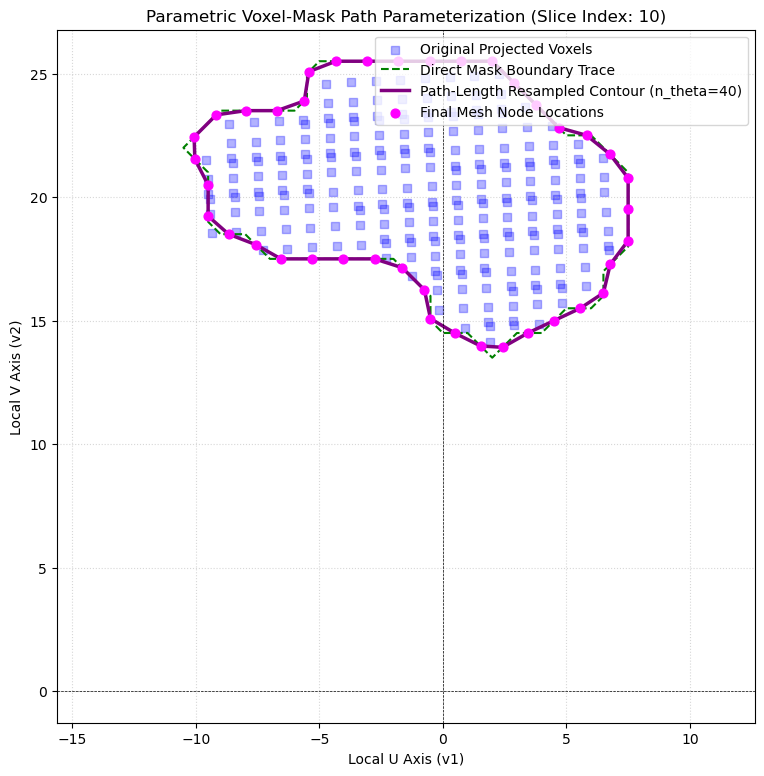

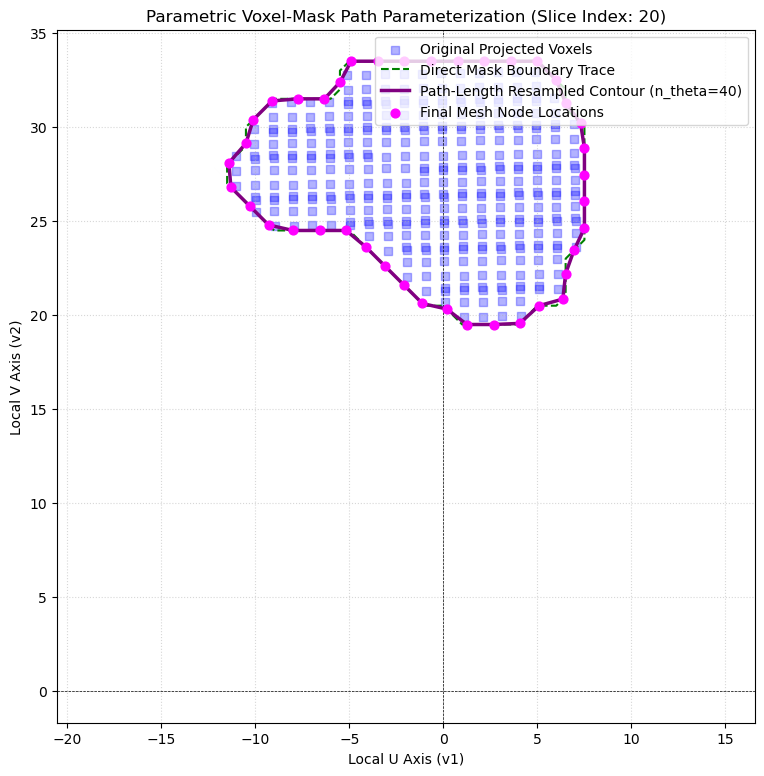

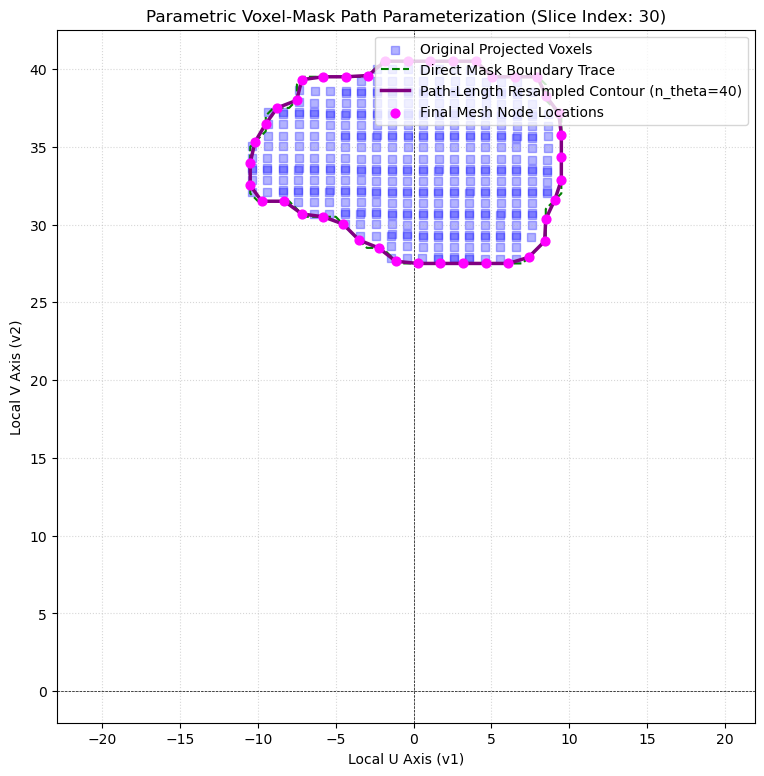

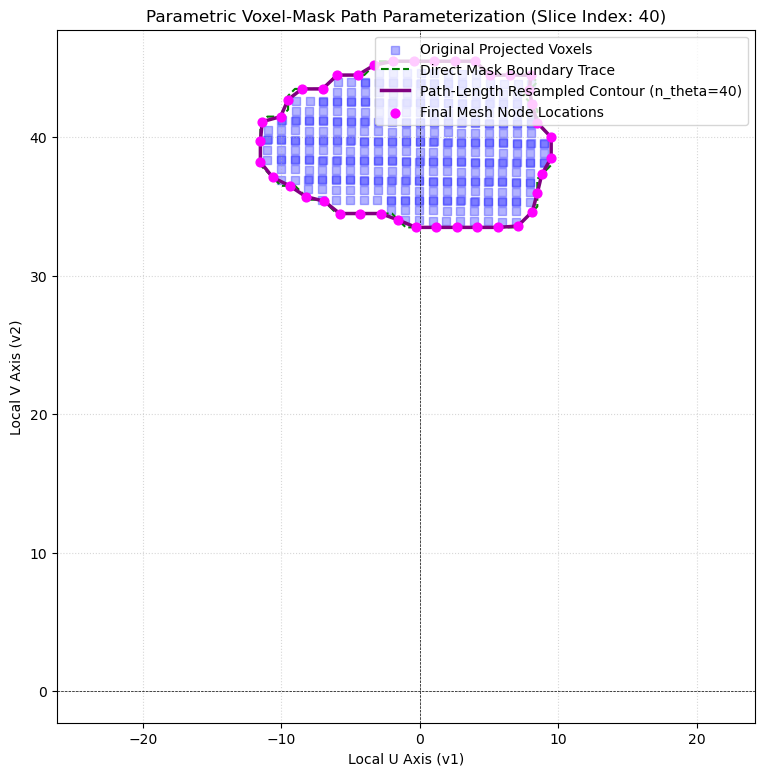

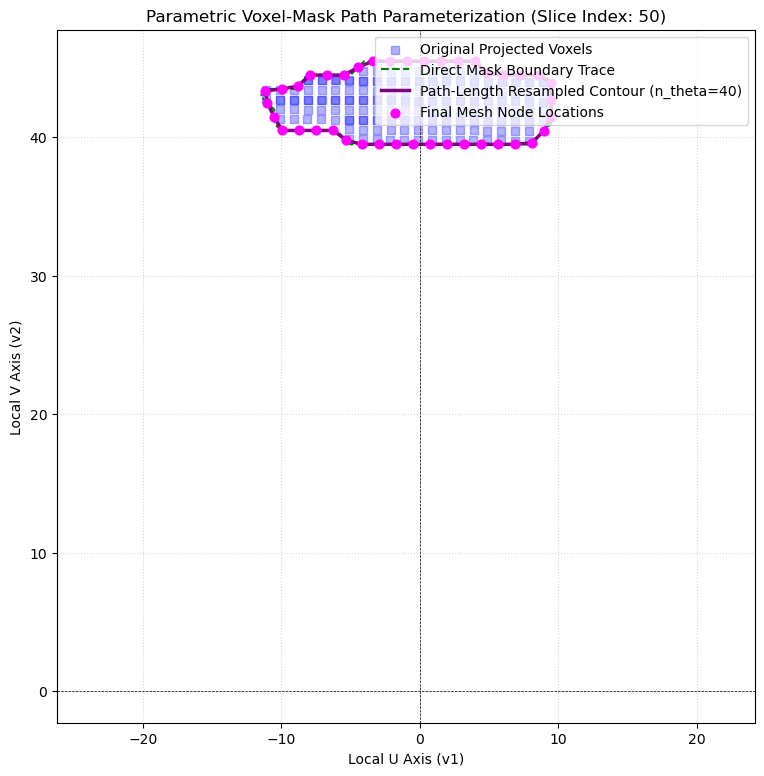

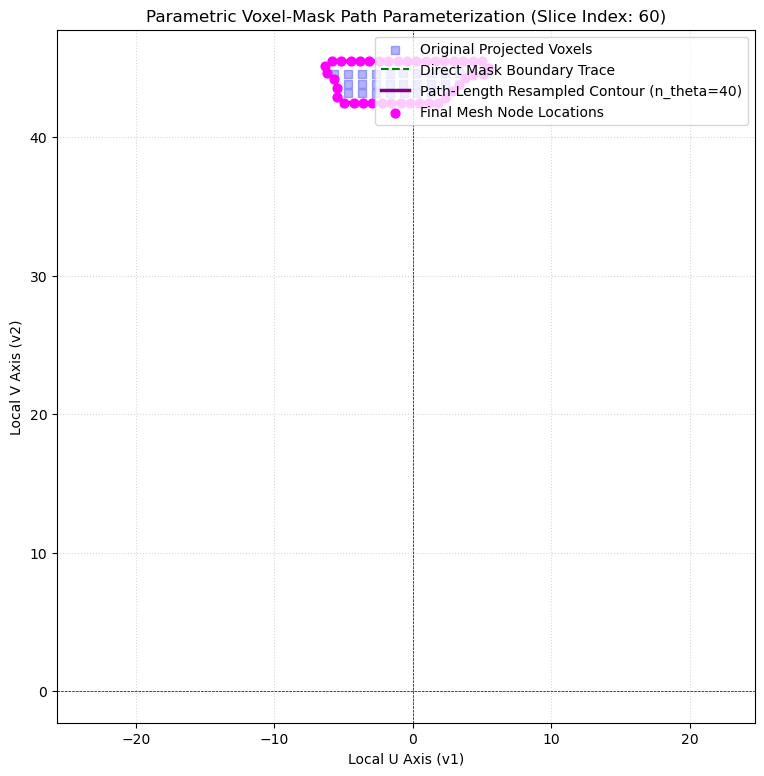

Slice 70 has too few slice voxels to process.
Slice 80 has too few slice voxels to process.
Slice 90 has too few voxels nearby.
Slice 100 has too few voxels nearby.


In [ ]:
from skimage import measure  


def plot_parametric_path_mask_contour(centerlines, mask, pixel_spacing, mid_idx, n_theta=64):
    """
    Extracts a 2D cross-section from a 3D binary mask, traces its perimeter 
    using marching squares, and resamples it into a uniform parametric array 
    based on cumulative path length to cleanly handle non-convex shapes.
    """
    # -------------------------------------------------------------------------
    # 1. Isolate the middle slice in voxel space
    # -------------------------------------------------------------------------
    centerline_data = centerlines[0]

    p = centerline_data[mid_idx]
    
    direction = (
        centerline_data[min(mid_idx + 1, len(centerline_data) - 1)]
        - centerline_data[max(mid_idx - 1, 0)]
    )
    direction /= numpy.linalg.norm(direction)
    v1, v2 = get_local_frame(direction)
    
    # Grab all coordinates where the mask is active
    voxel_coords = numpy.argwhere(mask)
    if len(voxel_coords) == 0:
        print("Mask is empty!")
        return
        
    # Query voxels inside a local neighborhood radius (45 voxels) around the node
    tree = cKDTree(voxel_coords)
    idx = tree.query_ball_point(p, r=45)
    
    if len(idx) < 15:
        print(f"Slice {mid_idx} has too few voxels nearby.")
        return
        
    local_voxels = voxel_coords[idx] - p
    
    # Slice selection: project onto plane normal and take a thin slab (+/- 1.0 voxel)
    dist_plane = numpy.dot(local_voxels, direction)
    slab = numpy.abs(dist_plane) < 1.0
    local_voxels = local_voxels[slab]
    
    if len(local_voxels) < 5:
        print(f"Slice {mid_idx} has too few slice voxels to process.")
        return
        
    # Project 3D voxel offsets onto the local 2D plane coordinates
    x = local_voxels @ v1
    y = local_voxels @ v2
    
    # -------------------------------------------------------------------------
    # 2. Extract Boundary Contour directly from the 2D Point Distribution
    # -------------------------------------------------------------------------
    # To run a robust marching squares contour finder, we map our projected points
    # onto a dense temporary 2D mini-grid canvas.
    padding = 3
    x_min, x_max = int(numpy.floor(numpy.min(x))) - padding, int(numpy.ceil(numpy.max(x))) + padding
    y_min, y_max = int(numpy.floor(numpy.min(y))) - padding, int(numpy.ceil(numpy.max(y))) + padding
    
    grid_w = x_max - x_min
    grid_h = y_max - y_min
    
    canvas = numpy.zeros((grid_h, grid_w), dtype=numpy.uint8)
    
    # Rasterize our slice voxels onto the canvas
    canvas_x = numpy.clip(numpy.round(x - x_min).astype(int), 0, grid_w - 1)
    canvas_y = numpy.clip(numpy.round(y - y_min).astype(int), 0, grid_h - 1)
    canvas[canvas_y, canvas_x] = 1
    
    # Find the outer boundary contours at an iso-value of 0.5
    contours = measure.find_contours(canvas, 0.5)
    if not contours:
        print("Could not isolate a clean mask contour for this slice.")
        return
        
    # Grab the largest continuous contour loop found in the slice
    main_contour = max(contours, key=len)
    
    # Map back from canvas pixel coordinates to our physical local 2D x, y space
    hull_pts = numpy.zeros_like(main_contour)
    hull_pts[:, 0] = main_contour[:, 1] + x_min # Canvas column is X
    hull_pts[:, 1] = main_contour[:, 0] + y_min # Canvas row is Y

    # -------------------------------------------------------------------------
    # 3. Parametric Encoding: Resample by Path Length (handles folds/crescents)
    # -------------------------------------------------------------------------
    # Distance between consecutive points along the contour perimeter
    segment_lengths = numpy.sqrt(numpy.sum(numpy.diff(hull_pts, axis=0)**2, axis=1))
    
    # Generate the cumulative distance array
    cumulative_distance = numpy.concatenate(([0], numpy.cumsum(segment_lengths)))
    total_length = cumulative_distance[-1]
    
    # Create an evenly spaced target grid along the total perimeter length
    target_distances = numpy.linspace(0, total_length, n_theta, endpoint=False)
    
    # Linearly interpolate the X and Y coordinates independently based on distance path
    parametric_x = numpy.interp(target_distances, cumulative_distance, hull_pts[:, 0])
    parametric_y = numpy.interp(target_distances, cumulative_distance, hull_pts[:, 1])

    # Close loops for drawing purposes
    parametric_x_closed = numpy.append(parametric_x, parametric_x[0])
    parametric_y_closed = numpy.append(parametric_y, parametric_y[0])

    # -------------------------------------------------------------------------
    # 4. Plotting
    # -------------------------------------------------------------------------
    plt.figure(figsize=(9, 9))
    
    # 1. Original voxel projections
    plt.scatter(x, y, color='blue', alpha=0.3, s=35, marker='s', label='Original Projected Voxels')
    
    # 2. Raw Marching Squares Boundary Trace
    plt.plot(hull_pts[:, 0], hull_pts[:, 1], color='green', linewidth=1.5, 
             linestyle='--', label='Direct Mask Boundary Trace')
    
    # 3. Parametric Path-Resampled Contour
    plt.plot(parametric_x_closed, parametric_y_closed, color='purple', linewidth=2.5, 
             label=f'Path-Length Resampled Contour (n_theta={n_theta})')
    
    # 4. Explicitly mark vertex points
    plt.scatter(parametric_x, parametric_y, color='magenta', s=40, zorder=5, 
                label='Final Mesh Node Locations')
    
    plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
    plt.axvline(0, color='black', linewidth=0.5, linestyle='--')
    plt.axis('equal')
    plt.title(f"Parametric Voxel-Mask Path Parameterization (Slice Index: {mid_idx})")
    plt.xlabel("Local U Axis (v1)")
    plt.ylabel("Local V Axis (v2)")
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.show()

muscle_id=2
print(muslce_ids[muscle_id])
for i in range(11):

    plot_parametric_path_mask_contour(
        centerlines=extended_centerlines_1, 
        mask=muscles[muscle_id], 
        pixel_spacing=pixel_spacing, 
        mid_idx = i*10,
        n_theta=40
)